### 4b. Theta Length at some particular transitions vs Learning Speed at that transition

In [1]:
%reload_ext autoreload
%autoreload 2

In [326]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.changeOfMind_DeltaT import get_GLM_elements_day, tuples2pd, violin_plot, scatter_plot
from scipy.stats import ranksums
import starbars

### set parameters of which theta decode dataset to use.

In [306]:
proportion = 0.1
delta_t_minus = 0
delta_t_plus = 2
max_flag = 0

transitions_1, transitions_2, transitions_3 = {}, {}, {}

In [308]:
animal = 'Eliot'
dates_to_plot = ['20221019','20221020','20221021']

transitions_final = [(2,1), (3,4)] #the new transitions that the animal learns
transitions_initial = [(1,3), (2,3), (2,4)] #the transitions that the animal unlearns

params = {"proportion": proportion, "delta_t_minus": delta_t_minus, "delta_t_plus": delta_t_plus,
          "max_flag":max_flag}

transitions_1_day, transitions_2_day, transitions_3_day = {}, {}, {}
for d in dates_to_plot:
    transitions_1_day[d] = get_GLM_elements_day(animal, d, transitions_initial, type = "1", **params)
    transitions_2_day[d] = get_GLM_elements_day(animal, d, transitions_initial, type = "2", **params)
    transitions_3_day[d] = get_GLM_elements_day(animal, d, transitions_final, type = "3", **params)
    
transitions_1[animal] = tuples2pd(transitions_1_day, dates_to_plot)   
transitions_2[animal] = tuples2pd(transitions_2_day, dates_to_plot)    
transitions_3[animal] = tuples2pd(transitions_3_day, dates_to_plot)   

[2025-09-22 15:17:38,213][WARNING]: Skipped checksum for file with hash: d969f004-166c-7a1a-8043-a2f15d64ec16, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_SDCFEY0OGA.nwb
[2025-09-22 15:17:43,552][WARNING]: Skipped checksum for file with hash: e69dbd79-c328-b330-3420-399cdae60977, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_1BNT2XVP33.nwb


potential_trials [ 9 25 29 33 48 56 60 66 76 80]
potential_trials [ 3  7 44 72]
potential_trials [11 15 23 27 31 50 54 62 78]
potential_trials [ 2  9 15 19 28 38 51 56 61 67 70]
potential_trials [33 42 46 74]
potential_trials [ 4  7 17 26 30 54 59 63]


[2025-09-22 15:17:49,283][WARNING]: Skipped checksum for file with hash: b2c3ab36-2552-2951-0b87-d152bb0610a9, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_ZOKTUHOZH5.nwb
[2025-09-22 15:17:54,484][WARNING]: Skipped checksum for file with hash: 09baefdd-134a-4b5a-b12a-8531ca9abd32, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_71UUC8IF2Q.nwb


potential_trials [19 23 32 36 43 50 54 58 63 68 74 78]
potential_trials []
potential_trials [ 4 10 14 17 27 34 41 52 56 76 81]


[2025-09-22 15:18:00,660][WARNING]: Skipped checksum for file with hash: 50fca833-43a5-1a8f-ca61-2dc318a0e741, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_C9OYHRCCQT.nwb


...

[2025-09-22 15:21:15,018][WARNING]: Skipped checksum for file with hash: 5c7a402c-7718-2e8a-f9b3-79013e226767, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_JRZDNENAAP.nwb


CoM_trials [10 26]
potential_trials [ 2  6 12 17 32 43 49 54 59 65 68 72 76 80]
CoM_trials []
potential_trials [21 38]
CoM_trials [11]
potential_trials [ 8 47 63 70]


[2025-09-22 15:21:20,330][WARNING]: Skipped checksum for file with hash: e3d4bdb0-7f01-4790-9169-f4a369e11ba1, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_BLL344WGO0.nwb


CoM_trials [76]
potential_trials [ 4 16 21 25 31 35 39 43 63 67 71 81]
CoM_trials []
potential_trials [13 53]
CoM_trials [75]
potential_trials [51 56 61 65 69 79]


[2025-09-22 15:21:25,515][WARNING]: Skipped checksum for file with hash: 9f0028d4-3d38-b1b3-2dfb-50a1cc94dad3, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_VCXAEAFGMA.nwb
[2025-09-22 15:21:30,704][WARNING]: Skipped checksum for file with hash: 7dd5e9f3-588e-eff3-ec17-3515f0a95a9a, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_J4I8WG9LP6.nwb
[2025-09-22 15:21:36,000][WARNING]: Skipped checksum for file with hash: 5c7a402c-7718-2e8a-f9b3-79013e226767, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_JRZDNENAAP.nwb


In [330]:
animal = 'Lewis'
animal_save = 'Lewis'
dates_to_plot = ['20240105','20240106','20240107','20240108','20240109','20240110']

transitions_final = [(4, 3)] #the new transitions that the animal learns
transitions_initial = [(4, 1)] #the transitions that the animal unlearns

params = {"proportion": proportion, "delta_t_minus": delta_t_minus, "delta_t_plus": delta_t_plus,
          "max_flag":max_flag}

transitions_1_day, transitions_2_day, transitions_3_day = {}, {}, {}
for d in dates_to_plot:
    transitions_1_day[d] = get_GLM_elements_day(animal, d, transitions_initial, type = "1", **params)
    transitions_2_day[d] = get_GLM_elements_day(animal, d, transitions_initial, type = "2", **params)
    transitions_3_day[d] = get_GLM_elements_day(animal, d, transitions_final, type = "3", **params)
    
transitions_1[animal_save] = tuples2pd(transitions_1_day, dates_to_plot)   
transitions_2[animal_save] = tuples2pd(transitions_2_day, dates_to_plot)    
transitions_3[animal_save] = tuples2pd(transitions_3_day, dates_to_plot)   

[2025-09-22 16:09:52,702][WARNING]: Skipped checksum for file with hash: be1bbe3a-9756-1488-944c-6adcf6508d65, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_YQHIT7PX7B.nwb
[2025-09-22 16:10:02,853][WARNING]: Skipped checksum for file with hash: a724b449-0e47-06c5-3a6f-b9ced900b065, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_CYFFJONLVI.nwb


potential_trials [ 2 12 22 37 54 60 65 73 78 96]


[2025-09-22 16:10:12,409][WARNING]: Skipped checksum for file with hash: d5e01e1d-aa55-3e05-b31c-58e7f2a7c256, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_Z4HDUAJEI2.nwb


potential_trials [10 31 40 45 51 56 71]


[2025-09-22 16:10:22,183][WARNING]: Skipped checksum for file with hash: 8a103a11-613e-ac9a-5c2b-29ac8cd0f308, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_09LWH6HBU6.nwb


...

[2025-09-22 16:21:22,145][WARNING]: Skipped checksum for file with hash: 434b1b44-3c36-12b5-96fa-f6b83805f4bb, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_UJHAFHTB8Y.nwb


CoM_trials []
potential_trials [34]


[2025-09-22 16:21:31,320][WARNING]: Skipped checksum for file with hash: 50216eb9-c3f8-b02a-5e4b-ea4d877de362, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_DLPP1TUZF2.nwb


CoM_trials [35]
potential_trials [ 6 25 32]


[2025-09-22 16:21:40,429][WARNING]: Skipped checksum for file with hash: 83c1b605-6c95-7134-b279-f9ae5da1af01, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_MW7DXODPPJ.nwb
[2025-09-22 16:21:49,482][WARNING]: Skipped checksum for file with hash: 74fff9e7-c971-1ac1-744b-523fc2eecd74, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_SDFSE0I28N.nwb
[2025-09-22 16:21:58,481][WARNING]: Skipped checksum for file with hash: 1f8190b7-3abd-0a05-7b24-fe01612d84d5, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_HSK7F8R3AM.nwb
[2025-09-22 16:22:07,698][WARNING]: Skipped checksum for file with hash: 434b1b44-3c36-12b5-96fa-f6b83805f4bb, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_UJHAFHTB8Y.nwb


### Plotting

### A) Theta deviation vs number of trials to repeat.
### B) Change of mind, Theta length vs number of trials to repeat
- Plot 1: Number of trials to repeat the transition for trials (a) with a change of mind from the initial choice (b) without a change of mind
- Plot 2: Number of trials to repeat the transition for trials (a) with a change of mind and long theta from the initial choice (b) without a change of mind and long theta from the initial choice
- Plot 3: Number of trials to repeat the transition for trials (a) with a change of mind to the final choice (b) without a change of mind
- Plot 4: Number of trials to repeat the transition for trials (a) with a change of mind and long theta from the final choice (b) without a change of mind and long theta from the final choice

p_value 0.6718854513890853
p_value 0.37809652033141794
p_value 0.9645581507166165
p_value 0.9720741574280346


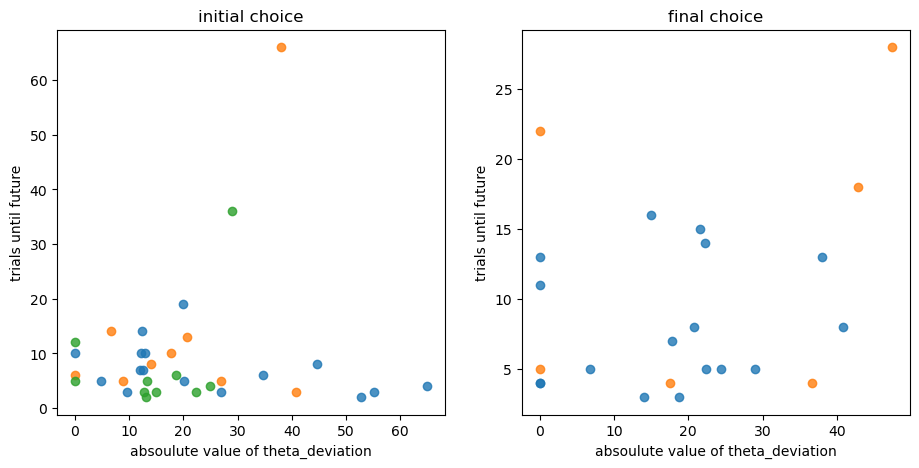

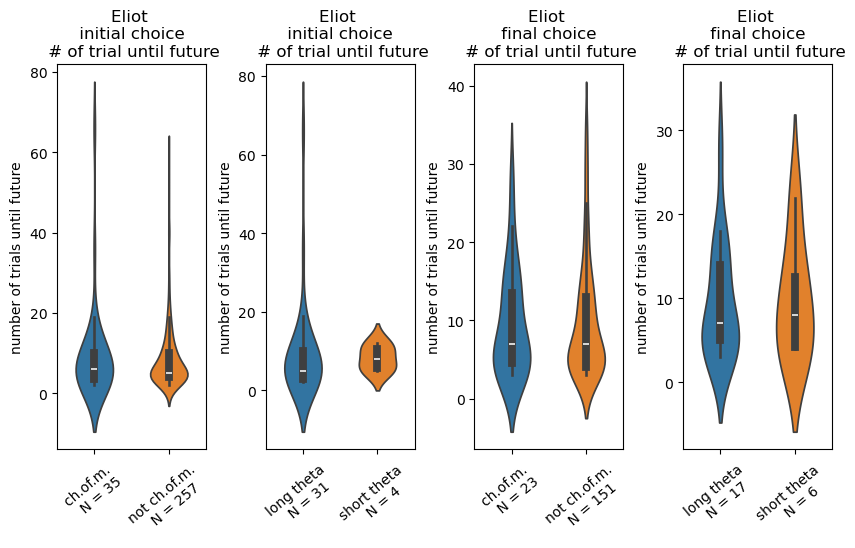

In [328]:
animal = 'Eliot'
transitions_1_animal = transitions_1[animal]
transitions_2_animal = transitions_2[animal]
transitions_3_animal = transitions_3[animal]

scatter_plot(transitions_2_animal, transitions_3_animal)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))
# Adjust the spacing
plt.subplots_adjust(wspace=0.4) # wspace for horizontal, hspace for vertical

violin_plot(transitions_1_animal, None, "is_change_of_mind", axes[0], animal, "initial choice")
violin_plot(transitions_2_animal, None, "theta_deviation", axes[1], animal, "initial choice")
violin_plot(transitions_3_animal, None, "is_change_of_mind", axes[2], animal, "final choice")
violin_plot(transitions_3_animal, None, "theta_deviation", axes[3], animal, "final choice")

p_value 0.5982329817146776
p_value 0.06440092350235385
p_value 0.5444284832679978
p_value 0.748816374270342


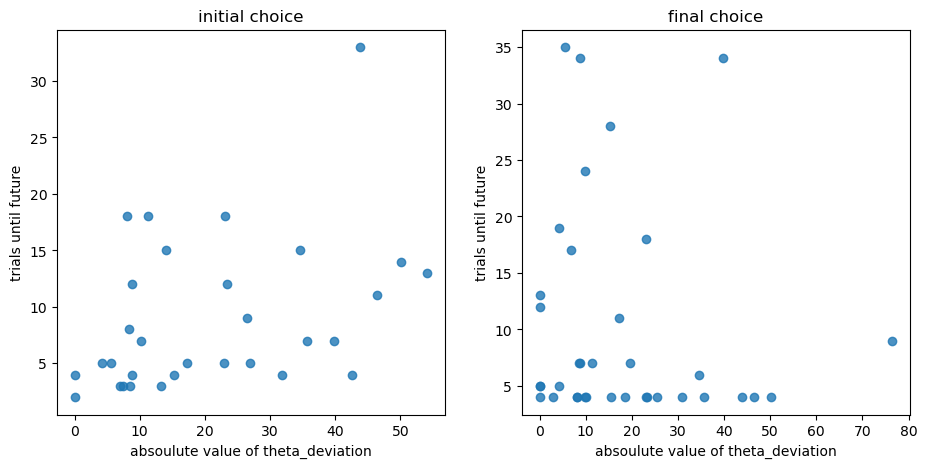

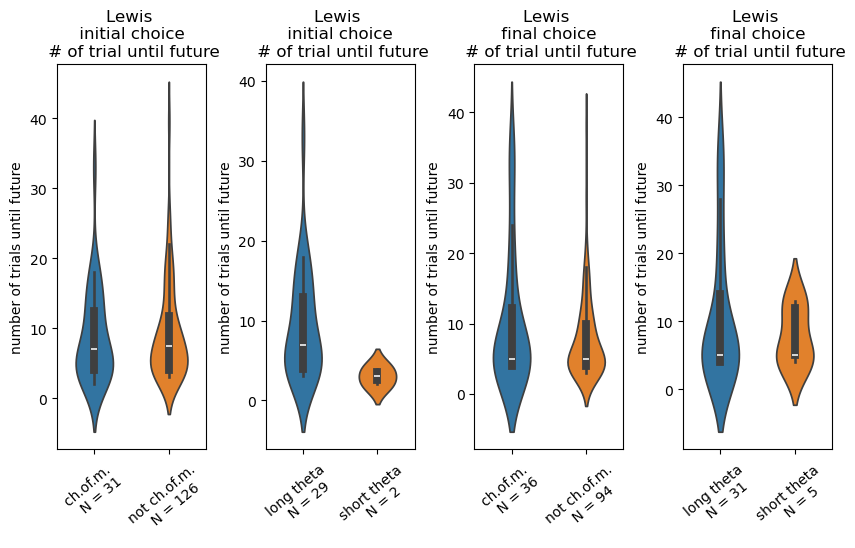

In [332]:
animal = 'Lewis'
transitions_1_animal = transitions_1[animal]
transitions_2_animal = transitions_2[animal]
transitions_3_animal = transitions_3[animal]

scatter_plot(transitions_2_animal, transitions_3_animal)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))
# Adjust the spacing
plt.subplots_adjust(wspace=0.4) # wspace for horizontal, hspace for vertical

violin_plot(transitions_1_animal,None, "is_change_of_mind", axes[0], animal, "initial choice")
violin_plot(transitions_2_animal,None, "theta_deviation", axes[1], animal, "initial choice")
violin_plot(transitions_3_animal,None, "is_change_of_mind", axes[2], animal, "final choice")
violin_plot(transitions_3_animal,None, "theta_deviation", axes[3], animal, "final choice")

### End here

In [299]:
df_glm = transitions_final_pd_[(1,3)]
data = df_glm[df_glm.is_change_of_mind]

In [300]:
data

,trials,trials_until_future,theta_deviation,is_change_of_mind,current_reward,nwb_file,session
16,56,5,0.000000,True,1.0,eliot20221019_.nwb,04_Seq2Session2
25,54,4,23.406516,True,1.0,eliot20221019_.nwb,06_Seq2Session3
52,24,4,13.237089,True,2.0,eliot20221020_.nwb,02_Seq2Session1
94,52,16,0.000000,True,2.0,eliot20221020_.nwb,10_Seq2Session5
129,54,5,16.874103,True,2.0,eliot20221021_.nwb,06_Seq2Session3
